In [ ]:
import pandas as pd

In [ ]:
metadata = pd.read_csv("/srv/data/jstor/jstor2025-06/metadata.csv", low_memory=False)
metadata.head()

In [ ]:
import nltk
metadata = metadata[(metadata['publicationYear'] >= 1900) & (metadata['docType'] == 'article')]
freq_dist = nltk.FreqDist(metadata['keyphrase'].dropna().str.split(';').explode())
freq_dist.most_common(20)


In [ ]:
import gzip
import json
import glob
import pandas as pd

def jsonl_extract():
    for filename in glob.glob('/srv/data/jstor/jstor2025-06/*.jsonl.gz'):
        with gzip.open(filename, 'rt', encoding='utf-8') as f:
            for line in f:
                yield json.loads(line)

jstor_df = pd.DataFrame(jsonl_extract())
jstor_df.head()

In [ ]:
%%time
analytic_keywords = [
    "logic", "language", "truth", "proposition", "analytic", "wittgenstein",
    "frege", "russell", "quine", "carnap", "verification", "meaning",
    "epistemology", "metaphysics", "mind", "science", "empiricism"
]
continental_keywords = [
    "phenomenology", "hermeneutics", "existentialism", "dialectic", "hegel",
    "heidegger", "sartre", "derrida", "foucault", "nietzsche", "deleuze",
    "structure", "postmodern", "subjectivity", "power", "difference",
    "being", "ontology"
]

analytic_ids = []
continental_ids = []

for idx, row in jstor_df.iterrows():
    text = str(row.get('fullText', '')).lower()
    if any(k in text for k in analytic_keywords):
        analytic_ids.append(idx)
    if any(k in text for k in continental_keywords):
        continental_ids.append(idx)

# Now analytic_ids and continental_ids contain row indices for each group

print(f"Analytic articles: {len(analytic_ids)}")
print(f"Continental articles: {len(continental_ids)}")

In [ ]:
import pickle

# Save analytic_ids
with open('analytic_ids.pkl', 'wb') as f:
    pickle.dump(analytic_ids, f)

# Save continental_ids
with open('continental_ids.pkl', 'wb') as f:
    pickle.dump(continental_ids, f)

# jstor2026-03

In [1]:
import json
import pandas as pd
import random
import nltk

In [ ]:
file_path = '/srv/data/jstor/jstor2026-03/jstor_metadata_2026-03-05.jsonl'

discipline_names = []
with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        obj = json.loads(line)
        # discipline_names may be a list or missing
        names = obj.get('discipline_names')
        if names:
            discipline_names.extend(names)

freq_dist = nltk.FreqDist(discipline_names)
print(freq_dist.most_common(100))

In [ ]:
# filter for articles in English in the 11 disciplines we care about
file_path = '/srv/data/jstor/jstor2026-03/jstor_metadata_2026-03-05.jsonl'

list_of_disciplines = [
    'Language & Literature', 'History', 'Political Science', 'Education', 'Sustainability', 'Philosophy',
    'Sociology', 'Classical Studies', 'Art & Art History', 'Anthropology', 'Linguistics'
]

rows = []
with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        obj = json.loads(line)
        discipline = obj.get('discipline_names', [])
        if (
            obj.get('content_type') == 'article' and
            obj.get('languages') == ['eng'] and
            obj.get('content_subtype') == 'research-article' and
            (
                (isinstance(discipline, list) and any(d in list_of_disciplines for d in discipline)) or
                (isinstance(discipline, str) and discipline in list_of_disciplines)
            )
        ):
            rows.append(obj)

df_filtered = pd.DataFrame(rows)

In [ ]:
df_filtered.to_csv('../data/large-data/jstor_metadata_2026-03-05-filtered.csv', index=False)

In [3]:
metadata = pd.read_csv('../data/large-data/jstor_metadata_2026-03-05-filtered.csv', low_memory=False)

In [6]:
disciplines = nltk.FreqDist(
    metadata['discipline_names']
    .dropna()
    .str.strip("[]")                # Remove brackets
    .str.replace("'", "")           # Remove single quotes
    .str.split(",")                 # Split by comma
    .explode()                      # Flatten
    .str.strip()                    # Remove extra spaces    
)
print(disciplines.most_common(20))

[('Language & Literature', 632352), ('Political Science', 395502), ('Sustainability', 358274), ('History', 328362), ('Education', 293296), ('Security Studies', 222209), ('Peace & Conflict Studies', 175579), ('Art & Art History', 175250), ('Military Studies', 136394), ('Asian Studies', 130633), ('Philosophy', 117724), ('American Studies', 111203), ('Economics', 104420), ('Sociology', 97846), ('International Relations', 94098), ('Anthropology', 83989), ('Classical Studies', 82629), ('Biological Sciences', 77148), ('Business', 69369), ('General Science', 64363)]


In [5]:
collections = (
    metadata['collections']
    .dropna()
    .str.strip("[]")                # Remove brackets
    .str.replace("'", "")           # Remove single quotes
    .str.split(",")                 # Split by comma
    .explode()                      # Flatten
    .str.strip()                    # Remove extra spaces
)
freq_dist = nltk.FreqDist(collections)
print(freq_dist.most_common(100))

[('Corporate & For-Profit Collection', 342378), ('Corporate & For-Profit Access Initiative Collection', 341440), ('Sustainability', 239045), ('Arts & Sciences VIII Collection', 205108), ('Arts & Sciences V Collection', 195778), ('Security Studies', 174972), ('Arts & Sciences VI Collection', 154018), ('Arts & Sciences I Collection', 151628), ('Arts & Sciences II Collection', 140181), ('Arts & Sciences III Collection', 133120), ('Arts & Sciences XI Collection', 129852), ('Sustainability Extension', 129025), ('Asia Collection', 123390), ('Arts & Sciences VII Collection', 119520), ('Arts & Sciences XV Collection', 111910), ('Language & Literature Collection', 107771), ('Life Sciences Collection', 90173), ('Business II Collection', 77992), ('Arts & Sciences IV Collection', 76297), ('For-Profit Academic Arts & Sciences IV Collection', 76297), ('Arts & Sciences XIII Collection', 72349), ('Ireland Collection', 65996), ('Arts & Sciences X Collection', 65970), ('Arts & Sciences XII Collection', 

In [ ]:
philosophy_articles = metadata[metadata['discipline_names'].str.contains('Philosophy')]


117724


In [2]:
# filter for articles in all languages
file_path = '/srv/data/jstor/jstor2026-03/jstor_metadata_2026-03-05.jsonl'

list_of_disciplines = [
    'Language & Literature', 'History', 'Political Science', 'Education', 'Sustainability', 'Philosophy',
    'Sociology', 'Classical Studies', 'Art & Art History', 'Anthropology', 'Linguistics'
]

rows = []
with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        obj = json.loads(line)
        discipline = obj.get('discipline_names', [])
        if (
            obj.get('content_type') == 'article' and
            obj.get('content_subtype') == 'research-article' and
            (
                (isinstance(discipline, list) and any(d in list_of_disciplines for d in discipline)) or
                (isinstance(discipline, str) and discipline in list_of_disciplines)
            )
        ):
            rows.append(obj)

df_filtered = pd.DataFrame(rows)

In [ ]:
philosophy_mask = df_filtered['discipline_names'].astype(str).str.contains('Philosophy')
languages_philosophy = df_filtered.loc[philosophy_mask, 'languages'].dropna().explode()
fdist_philosophy = nltk.FreqDist(languages_philosophy)
print(fdist_philosophy.most_common(20))

[('eng', 118344), ('fre', 53575), ('ger', 8466), ('ita', 8088), ('en', 3387), ('spa', 2693), ('pol', 2553), ('por', 2180), ('dut', 1996), ('heb', 1323), ('lat', 682), ('pl', 25), ('es', 19), ('gle', 18), ('rus', 13), ('afr', 8), ('fr', 4), ('gre', 4), ('san', 3), ('ara', 2)]


In [ ]:
philosophy_eng = df_filtered.loc[philosophy_mask]
philosophy_eng = philosophy_eng[philosophy_eng['languages'].apply(lambda x: 'eng' in x if isinstance(x, list) else x == 'eng')]
print(len(philosophy_eng))

/tmp/ipykernel_221025/2954531751.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered.loc[philosophy_mask, 'year'] = pd.to_datetime(df_filtered.loc[philosophy_mask, 'published_date'], errors='coerce').dt.year


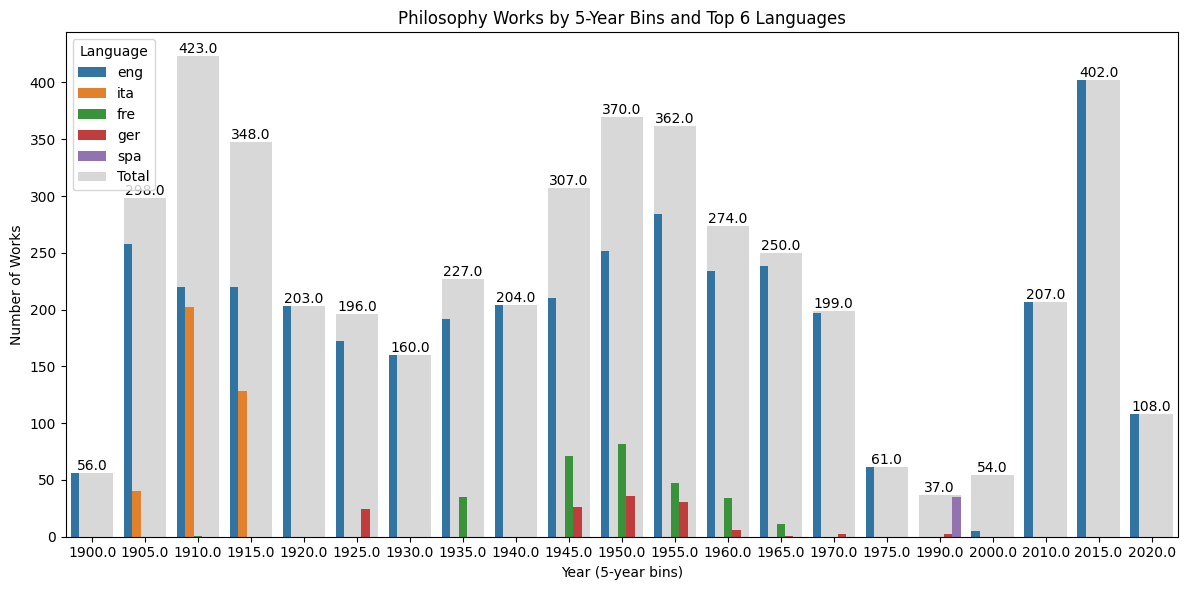

In [ ]:
# ...existing code...

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

philosophy_mask = df_filtered['discipline_names'].astype(str).str.contains('Philosophy')

# Extract year from published_date
df_filtered.loc[philosophy_mask, 'year'] = pd.to_datetime(df_filtered.loc[philosophy_mask, 'published_date'], errors='coerce').dt.year
df_filtered.loc[philosophy_mask, 'year_bin'] = (df_filtered.loc[philosophy_mask, 'year'] // 5) * 5

# Normalize languages: treat 'en' and 'eng' as 'eng'
def normalize_langs(langs):
    if isinstance(langs, list):
        return [l if l not in ['en', 'eng'] else 'eng' for l in langs]
    elif langs in ['en', 'eng']:
        return 'eng'
    else:
        return langs

df_filtered.loc[philosophy_mask, 'languages_norm'] = df_filtered.loc[philosophy_mask, 'languages'].apply(normalize_langs)

# Find top 6 languages after normalization
lang_series = df_filtered.loc[philosophy_mask, 'languages_norm'].dropna()
lang_flat = lang_series.explode() if lang_series.apply(lambda x: isinstance(x, list)).any() else lang_series
top_langs = lang_flat.value_counts().head(6).index.tolist()

def lang_group(langs):
    if isinstance(langs, list):
        for l in langs:
            if l in top_langs:
                return l
        return None
    elif langs in top_langs:
        return langs
    else:
        return None

df_filtered.loc[philosophy_mask, 'lang_group'] = df_filtered.loc[philosophy_mask, 'languages_norm'].apply(lang_group)

# Group for total works per bin
total_df = (
    df_filtered.loc[philosophy_mask]
    .groupby('year_bin')
    .size()
    .reset_index(name='total_count')
)

# Group for top 6 languages per bin
plot_df = (
    df_filtered.loc[philosophy_mask]
    .dropna(subset=['lang_group'])
    .groupby(['year_bin', 'lang_group'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(12, 6))

# Plot total works in gray
ax = sns.barplot(
    data=total_df,
    x='year_bin',
    y='total_count',
    color='gray',
    alpha=0.3,
    label='Total'
)

# Overlay language bars
sns.barplot(
    data=plot_df,
    x='year_bin',
    y='count',
    hue='lang_group',
    ax=ax
)

# Add total counts on top of gray bars
for idx, row in total_df.iterrows():
    ax.text(
        idx,
        row['total_count'],
        str(row['total_count']),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.xlabel('Year (5-year bins)')
plt.ylabel('Number of Works')
plt.title("Philosophy Works by 5-Year Bins and Top 6 Languages")
plt.legend(title='Language')
plt.tight_layout()
plt.show()

# ...existing code...

In [13]:
# ...existing code...

import numpy as np

# Get counts of 'eng' works per bin
eng_counts = (
    plot_df[plot_df['lang_group'] == 'eng']
    .sort_values('year_bin')
)

# Fit linear trend and print slope
if not eng_counts.empty:
    x = eng_counts['year_bin'].values
    y = eng_counts['count'].values
    slope, intercept = np.polyfit(x, y, 1)
    print(f"Slope of 'eng' trend: {slope:.3f} works per 5-year bin")

# ...existing code...

Slope of 'eng' trend: -0.002 works per 5-year bin
